In [1]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import shapely.vectorized as sv

from multiprocessing import Pool
from joblib import Parallel, delayed

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw
from function import ART_downscale

In [2]:
npix = 2
yy_s, yy_e = 2002, 2023
NEIBHR = 2*npix+1

In [3]:
# product, time_reso = 'IMERG', '3h'
# product, time_reso = 'CMORPH', '3h'
# product, time_reso = 'MSWEP', '3h'
# product, time_reso = 'ERA5', '3h'
# product, time_reso = 'GSMaP', '3h'
product, time_reso = 'CHIRPS', '1dy'

In [4]:
# PADOVA
lon_min, lon_max, lat_min, lat_max, area = 11, 12.5, 45, 46, 'PADOVA'
# VENETO
# lon_min, lon_max, lat_min, lat_max, area = 10.5, 13.5, 44.5, 47, 'VENETO'
# ITALY
# lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'

In [5]:
if area == 'PADOVA':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Padova.geojson'))
elif area == 'VENETO':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Veneto.geojson'))
elif area == 'ITALY':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Italy_simple.geojson'))
else:
    sys.exit("Area not recognized. Please choose 'VENETO' or 'ITALY'.")

GEOMETRY_union = GEOMETRY.union_all()

In [6]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [7]:
if product == 'IMERG':
    filename = 'IMERG_Italy_3h_2001_01_01_2023_12_31.nc'

elif product == 'CMORPH':
    filename = 'CMORPH_Italy_3hr_1998_01_01_2023_12_31.nc'

elif product == 'MSWEP':
    filename = 'MSWEP_Italy_3h_1980_01_01_2023_12_31.nc'

elif product == 'ERA5':
    filename = 'ERA5_Italy_3h_2000_01_01_2023_12_31.nc'

elif product == 'GSMaP':
    filename = 'GSMaP_Italy_3h_2002_01_01_2024_12_31.nc'

elif product == 'CHIRPS':
    filename = 'CHIRPS_Italy_1dy_1981_01_01_2024_06_30.nc'

else:
    sys.exit('Product not found')

In [8]:
if product == 'IMERG':
    origin = [10, 3]
    target = [0, 24]

elif product == 'CMORPH':
    origin = [25, 3]
    target = [0, 24]

elif product == 'MSWEP':
    origin = [10, 3]
    target = [0, 24]

elif product == 'ERA5':
    origin = [25, 3]
    target = [0, 24]

elif product == 'GSMaP':
    origin = [10, 3]
    target = [0, 24]

elif product == 'CHIRPS':
    origin = [5, 24]
    target = [0, 24]

print(f'Product: {product}')
print(f'xscale : {origin[0]} km to {target[0]} km')
print(f'tscale : {origin[1]} hr to {target[1]} hr')

Product: CHIRPS
xscale : 5 km to 0 km
tscale : 24 hr to 24 hr


In [9]:
print(f'Product: {product}')
dir_input = os.path.join(dir_base,product,time_reso,filename)
DATA = xr.open_dataset(dir_input)
DATA = DATA.sel(time=DATA.time.dt.year.isin(np.arange(yy_s,yy_e+1)))
DATA = DATA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
DATA = DATA.where(DATA>= -0.001)

lats = DATA['lat'].data
lons = DATA['lon'].data

lon2d, lat2d = np.meshgrid(lons, lats)
mask_study = sv.contains(GEOMETRY_union, lon2d, lat2d)

indices_lat, indices_lon = np.where(mask_study)

Product: CHIRPS


In [10]:
PRE_data_T = DATA.transpose('lon', 'lat', 'time')
time_vector_dt = pd.to_datetime(PRE_data_T['PRE']['time'].values)
DATA_3h = xr.DataArray(PRE_data_T['PRE'],  
                        coords={
                            'lon':PRE_data_T['lon'].values, 
                            'lat':PRE_data_T['lat'].values, 
                            'time':time_vector_dt},
                        dims=('lon', 'lat', 'time'))

In [11]:
thresh = 1
acf = 'mar'

la, lo = 10, 20

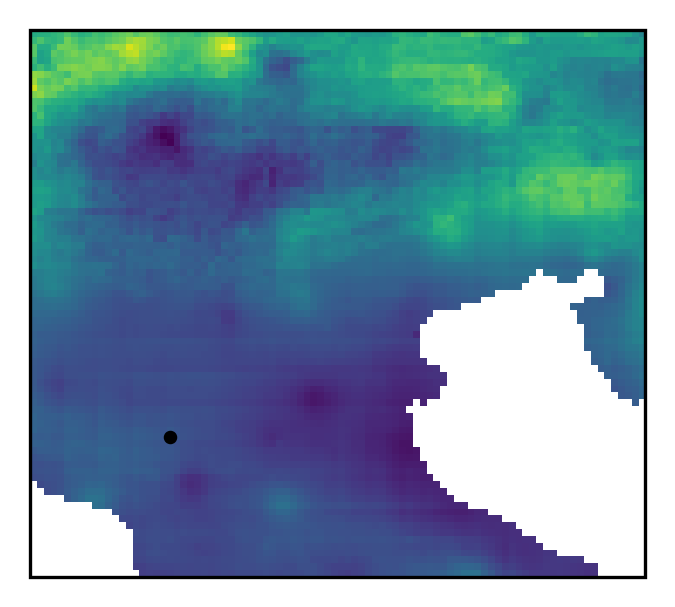

In [12]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9,3),dpi=300)
gs = gridspec.GridSpec(1,3)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.pcolormesh(lon2d, lat2d,np.sum(DATA_3h.values,axis=2).T)
ax1.scatter(lons[lo], lats[lo], s=5, c='k', zorder=10)

In [13]:
lat_c = lats[la]
lon_c = lons[lo]
box_3h = DOWN_raw.create_box_v2(DATA_3h, lat_c, lon_c, npix)

In [14]:
parnames = ['eps', 'alp'] if acf == 'mar' else ['d0', 'mu0']

In [15]:
rcorr_pearson = DOWN_raw.grid_corr(box_3h, plot=False, thresh=thresh, cor_method='pearson')
dcorr =  DOWN_raw.down_corr(rcorr_pearson['vdist'], rcorr_pearson['vcorr'], origin[0], acf=acf, use_ave=True, opt_method='genetic', toll=0.005,plot=True)
par_acf = (dcorr['{}_d'.format(parnames[0])], dcorr['{}_d'.format(parnames[1])])
gam_pearson = DOWN_raw.vrf(origin[0], target[0], par_acf, acf=acf)
gam_pearson

0.9408760983195223

In [16]:
rcorr_spearman = DOWN_raw.grid_corr(box_3h, plot=False, thresh=thresh, cor_method='spearman')
dcorr =  DOWN_raw.down_corr(rcorr_spearman['vdist'], rcorr_spearman['vcorr'], origin[0], acf=acf, use_ave=True, opt_method='genetic', toll=0.005,plot=True)
par_acf = (dcorr['{}_d'.format(parnames[0])], dcorr['{}_d'.format(parnames[1])])
gam_spearman = DOWN_raw.vrf(origin[0], target[0], par_acf, acf=acf)
gam_spearman

0.8842300095596478

In [17]:
rcorr_spearman = DOWN_raw.grid_corr(box_3h, plot=False, thresh=thresh, cor_method='spearman')
dcorr =  DOWN_raw.down_corr(rcorr_spearman['vdist'], rcorr_spearman['vcorr'], origin[0], acf=acf, use_ave=True, opt_method='genetic', toll=0.005,plot=True)
par_acf = (dcorr['{}_d'.format(parnames[0])], dcorr['{}_d'.format(parnames[1])])
gam_spearman = DOWN_raw.vrf(origin[0], target[0], par_acf, acf=acf)
gam_spearman

0.8842300095596478

In [18]:
gam_pearson, gam_spearman

(0.9408760983195223, 0.8842300095596478)

## Pearson 2 pix: 0.95709870898681
## Spearman 2 pix: 0.920310511031434

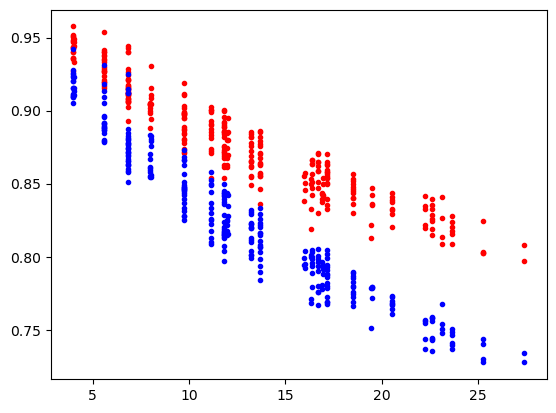

In [19]:
plt.plot(rcorr_pearson['vdist'],rcorr_pearson['vcorr'],'.',c='r')
plt.plot(rcorr_spearman['vdist'],rcorr_spearman['vcorr'],'.',c='b')

In [20]:
sys.exit()

SystemExit: 

/home/arturo/anaconda3/envs/AXE/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
from scipy.stats import pearsonr, spearmanr
from scipy.optimize import curve_fit, minimize, fsolve
from scipy.optimize import differential_evolution
from scipy.integrate import dblquad, nquad

In [ ]:
GL_N = 40  # nodos — subí si necesitás más precisión cerca del kink en epsilon
_gl_x, _gl_w = np.polynomial.legendre.leggauss(GL_N)

def integrate_2d_gl(func, a1, b1, a2, b2):
    x = 0.5*(b1-a1)*_gl_x + 0.5*(b1+a1)
    y = 0.5*(b2-a2)*_gl_x + 0.5*(b2+a2)
    wx = _gl_w * 0.5*(b1-a1)
    wy = _gl_w * 0.5*(b2-a2)
    X, Y = np.meshgrid(x, y, indexing='ij')
    Z = func(X, Y)
    return np.sum(np.outer(wx, wy) * Z)

def nabla_2d_fast(par_acf, myacf, T1, T2):
    if T1 == 0 or T2 == 0:
        return 0.0
    integrand = lambda x, y: (T1 - x) * (T2 - y) * myacf(x, y, par_acf)
    return 4.0 * integrate_2d_gl(integrand, 0.0, T1, 0.0, T2)

In [ ]:
def str_exp_fun(x, d0, mu):
    '''
    Stretched exponential rainfall correlation function
    from eg Habib and krajewski (2003)
    or Villarini and Krajewski (2007)
    with 2 parameters d0, mu (value as x = 0 is 1)
    '''
    x = np.asarray(x) # transform to numpy array
    is_scalar = False if x.ndim > 0 else True # create flag for output
    x.shape = (1,)*(1-x.ndim) + x.shape # give it dimension 1 if scalar
    myfun = np.exp( -(x/d0)**mu)
    myfun = myfun if not is_scalar else myfun[0]
    return  myfun

def epl_fun(x, epsilon, alpha):
    '''
    Marco's Exponential kernel + Power law tail
    (autocorrelation) function with exponential nucleus and power law decay
    for x> epsilon - 2 parameters
    see Marani 2003 WRR for more details
    '''
    x = np.asarray(x) # transform to numpy array
    is_scalar = False if x.ndim > 0 else True # create flag for output
    x.shape = (1,)*(1-x.ndim) + x.shape # give it dimension 1 if scalar
    m = np.size(x)
    myfun = np.zeros(m)
    for ii in range(m):
        if x[ii] < 10e-6:
            myfun[ii] = 1
        elif x[ii] < epsilon:
            myfun[ii] = np.exp(-alpha*x[ii]/epsilon)
        else:
            # silence it if negative parameters -
            # with warnings.simplefilter('ignore', RuntimeWarning):
            myfun[ii] = (epsilon/np.exp(1)/x[ii])**alpha
            # print('epsilon = ', epsilon)
            # if epsilon < 1e-5 or alpha < 1e-5:
            #     print('epsilon = ', epsilon)
            #     print('alpha =', alpha)
            # else:
    myfun = myfun if not is_scalar else myfun[0]
    return  myfun

def haversine(lat1, lat2, lon1, lon2,
                convert_to_rad=True):
    '''compute haversine distance btw 2 points.
    by default provide angles in degrees.
    Return distance in km'''

    def torad(theta):
        # convert angle to radiants
        return theta*np.pi/180.0

    if convert_to_rad:
        lat1 = torad(lat1)
        lat2 = torad(lat2)
        lon1 = torad(lon1)
        lon2 = torad(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    R = 6371.0 # km
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    dist = 2*R*np.arctan2( np.sqrt(a), np.sqrt(1-a))
    return dist

def vrf_v2(L, L0, par_acf, acf='mar'):
    """
    Compute the variance reduction factor (VRF).

    Parameters
    ----------
    L : float
        Spatial averaging scale (km).
    L0 : float
        Smaller reference scale (currently unused because the VRF is
        computed relative to a point).
    par_acf : tuple
        Parameters of the point autocorrelation function.
        ('eps','alp') for 'mar'
        ('d0','mu0') for 'str'
    acf : {'mar','str'}
        Autocorrelation function.

    Returns
    -------
    gam : float
        Variance reduction factor:
            Var[L] / Var(point)
    """

    def myacf(x, y):

        h = np.sqrt(x**2 + y**2)

        if acf == 'mar':
            return epl_fun(h, par_acf[0], par_acf[1])

        elif acf == 'str':
            return str_exp_fun(h, par_acf[0], par_acf[1])

        else:
            raise ValueError("acf must be 'mar' or 'str'")

    integrand = lambda x, y: (L - x) * (L - y) * myacf(x, y)

    integral, _ = dblquad(
        integrand,
        0.0,
        L,
        lambda x: 0.0,
        lambda x: L
    )

    gam = (4.0 / L**4) * integral

    return gam

def grid_corr_v2(xdata, plot=True, thresh=0, cor_method='pearson'):
    """
    Given an xarray with the data (dimensions: lat, lon, time)
    computes the correlation between each couple of grid cells
    and fits a correlation model.

    Missing values must already be set to NaN.
    """

    # ------------------------------------------------------------------
    # Remove timesteps containing NaNs anywhere in the box
    # ------------------------------------------------------------------
    xdata = xdata.dropna(dim='time', how='any')

    lats = xdata.lat.values
    lons = xdata.lon.values

    nlats = len(lats)
    nlons = len(lons)

    nelem = nlats * nlons

    lats9 = np.repeat(lats, nlons)
    lons9 = np.tile(lons, nlats)

    ncorr = nelem * (nelem - 1) // 2

    vcorr = np.full(ncorr, np.nan)
    vdist = np.zeros(ncorr)

    count = 0

    for i in range(nelem):

        tsi = xdata.loc[dict(lat=lats9[i], lon=lons9[i])].values
        tsi = np.maximum(tsi - thresh, 0.0)

        for j in range(i + 1, nelem):

            tsj = xdata.loc[dict(lat=lats9[j], lon=lons9[j])].values
            tsj = np.maximum(tsj - thresh, 0.0)

            # ----------------------------------------------------------
            # Correlation
            # ----------------------------------------------------------
            if np.std(tsi) == 0 or np.std(tsj) == 0:
                corr = np.nan

            else:
                if cor_method == "spearman":
                    corr, _ = spearmanr(tsi, tsj)

                elif cor_method == "pearson":
                    corr, _ = pearsonr(tsi, tsj)

                else:
                    raise ValueError(
                        "cor_method must be 'pearson' or 'spearman'"
                    )

            vcorr[count] = corr

            vdist[count] = haversine(
                lats9[i],
                lats9[j],
                lons9[i],
                lons9[j],
            )

            count += 1

    # ------------------------------------------------------------------
    # Remove invalid correlations
    # ------------------------------------------------------------------
    mask = np.isfinite(vcorr)

    vcorr = vcorr[mask]
    vdist = vdist[mask]

    res = dict()

    res["vdist"] = vdist
    res["vcorr"] = vcorr

    xx = np.linspace(np.min(vdist), np.max(vdist), 200)

    try:

        popt, _ = curve_fit(
            str_exp_fun,
            vdist,
            vcorr,
            p0=(50, 1),
            bounds=((0, 0), (np.inf, np.inf)),
            maxfev=12000,
        )

        res["d0_s"] = popt[0]
        res["mu0_s"] = popt[1]

        popt1, _ = curve_fit(
            epl_fun,
            vdist,
            vcorr,
            p0=(50, 1),
            bounds=((0, 0), (np.inf, np.inf)),
            maxfev=12000,
        )

        res["eps_s"] = popt1[0]
        res["alp_s"] = popt1[1]

    except RuntimeError as e:

        print(f"[WARNING] Fit failed: {e}")

        res["d0_s"] = np.nan
        res["mu0_s"] = np.nan
        res["eps_s"] = np.nan
        res["alp_s"] = np.nan

    if plot:

        fig = plt.figure()

        plt.plot(vdist, vcorr, "o", label="Empirical")

        plt.plot(
            xx,
            str_exp_fun(xx, res["d0_s"], res["mu0_s"]),
            "r",
            label="Stretched exponential",
        )

        plt.plot(
            xx,
            epl_fun(xx, res["eps_s"], res["alp_s"]),
            "g",
            label="Exponential power-law",
        )

        plt.xlabel("Distance (km)")
        plt.ylabel("Correlation")
        plt.xlim(np.min(vdist), np.max(vdist))
        plt.ylim(0, 1)

        plt.legend()

        plt.close()

        res["fig"] = fig

    return res

def myacf_2d(x,y, parhat, acf = 'str'):
    '''########################################################################
    set of 2D autocorrelation functions
    INPUTS::
        x,y = variables of the ACF
        parhat = set of the two parameters of the ACF
        acf: which ACF. possible choices:
            acf = 'str': stretched exponential ACF,
                WITH PARAMETERS: scale d0 and shape mu
            acf = 'mar': Marani 2003 exponential kernel + power law tail
                WITH PARAMETERS: transition point epsilon and shape alpha
            acf 'exp': 2d exponential function
                WITH PARAMETERS: a and b --> scale in x and y axis respectively
    OUTPUTS::
        value of the ACF at a point
    ########################################################################'''
    d = np.sqrt(x**2 + y**2)
    if acf == 'str': # par d0, mu0
        d0 = parhat[0]
        mu = parhat[1]
        return np.exp( -(d/d0)**mu)
    elif acf == 'mar': # par:: epsilon, alpha
        # print('it actually is a Power Law')
        epsilon = parhat[0]
        alpha   = parhat[1]
        return epl_fun(d, epsilon , alpha)

# def nabla_2d(par_acf, myacf, T1, T2, err_min = 1e-2):
#     '''########################################################################
#     Compute the variance function as in Vanmarcke's book.
#     INPUTS::
#         par_acf = tuple with the parameters of the autocorr function (ACF)
#         myacf = ACF in 1,2,or 3 dimensions, with parameters in par_acf
#         T1 = 1st dimension of averaging area
#         T2 = 2nd dim of the averaging area'''
#     if (T1 == 0) or (T2 == 0):
#         print('integration domain is zero')
#         return 0.0 # integral is zero in this case.
#     else:
#         # fun_XY = lambda x ,y: (T1 - x ) *(T2 - y ) *myacf(x ,y, par_acf)
#         # myint, myerr = nquad(fun_XY, [[0. ,T1], [0. ,T2]])

#         integrand = lambda y, x: (T1 - x) * (T2 - y) * myacf(x, y, par_acf)
#         myint, myerr = dblquad(integrand,0.0,T1,lambda x: 0.0,lambda x: T2)

#         # if myint != 0.0:
#         #     rel_err = myerr /myint
#         # else:
#         #     rel_err = 0
#         # if rel_err > err_min:
#         #     print('varfun ERROR --> Numeric Integration scheme does not converge')
#         #     print('int rel error = ', rel_err)
#         #     sys.exit("aargh! there are errors!") # to stop code execution
#         return 4.0 * myint

from functools import lru_cache
from scipy.integrate import nquad
import numpy as np

def nabla_2d(par_acf, myacf, T1, T2, err_min=1e-2):
    """
    Wrapper that converts the optimization parameters into a hashable tuple.
    """

    par_acf = tuple(np.asarray(par_acf, dtype=float))

    return _nabla_2d_cached(par_acf, myacf, float(T1), float(T2))


@lru_cache(maxsize=10000)
def _nabla_2d_cached(par_acf, myacf, T1, T2):
    """
    Cached version of Vanmarcke's variance function.
    """

    if T1 <= 0 or T2 <= 0:
        return 0.0

    fun_XY = lambda x, y: (
        (T1 - x) *
        (T2 - y) *
        myacf(x, y, par_acf)
    )

    myint, _ = nquad(
        fun_XY,
        [[0.0, T1], [0.0, T2]]
    )

    return 4.0 * myint


def fast_corla_2d(par_acf, myacf, Tx, L, err_min=1e-2):
    nab_1 = nabla_2d(par_acf, myacf, L, Tx[0], err_min=err_min)
    nab_2 = nabla_2d(par_acf, myacf, L, Tx[1], err_min=err_min)
    nab_3 = nabla_2d(par_acf, myacf, L, Tx[2], err_min=err_min)
    nab_den = nabla_2d(par_acf, myacf, L, L, err_min=err_min)
    if np.abs(nab_den) < 10e-6: # to avoid infinities
        # print('correcting - inf value')
        nab_den = 10e-6
    covla = 2*(nab_1 -2*nab_2 + nab_3)/(4*nab_den)
    # print('parhat =', par_acf)
    return covla

def myfun_sse(xx, yobs, parhat, L, acf = 'mar'):
    xx = np.asarray(xx)
    myacf = lambda x, y, parhat: myacf_2d(x, y, parhat, acf=acf)
    # Ty = np.array([L, 0., L, 0.])
    sse = 0
    m = np.size(xx)
    for ii in range(m):
        myx = xx[ii]
        Tx = np.array([np.abs(L - myx), myx, L + myx, myx])
        # L2 = [L, L]
        # res = corla_2d(L2, L2, parhat, myacf, Tx, Ty, err_min=1e-5)
        # faster option: - same result (optimized)
        res = fast_corla_2d(parhat, myacf, Tx, L, err_min=1e-2)
        sse = sse + (res - yobs[ii]) ** 2
        # sse = sse + ((res - yobs[ii])/yobs[ii]) ** 2 # norm
    # print('sse', sse)
    # print('parhat =', parhat)
    return sse

def bin_ave_corr(vdist, vcorr, toll=0.3, plot=False):
    ''' compute block averages to approximate
    the empirical correlation function'''
    vd = np.sort(vdist)
    cd = vcorr[np.argsort(vdist)]
    m = np.size(vd)
    cluster = np.zeros(m)
    count = 0
    for i in range(1, m):
        if np.abs(vd[i]-vd[i-1]) < toll:
            cluster[i] = count
        else:
            count = count + 1
            cluster[i] = count
    clust = set(cluster)
    nclust = len(clust)
    vdist_ave = np.zeros(nclust)
    vcorr_ave = np.zeros(nclust)
    for ei, elem in enumerate(clust):
        di = vd[cluster==elem]
        ci = cd[cluster==elem]
        vdist_ave[ei] = np.mean(di)
        vcorr_ave[ei] = np.mean(ci)
    res = {}
    res['vdist_ave'] = vdist_ave
    res['vcorr_ave'] = vcorr_ave
    res['vd'] = vd
    res['cd'] = cd
    res['cluster']  = cluster
    if plot:
        fig = plt.figure()
        plt.scatter(vd, cd, c=cluster, cmap='jet')
        plt.scatter(res['vdist_ave'], res['vcorr_ave'], c='k')
        # plt.show()
        plt.close()
        res['fig'] = fig
    return res

def int_corr(xx, parhat, acf, L):
    '''------------------------------------------------------------------------
    compute correlation of Local averages
    (inverse than the down_corr function)
    ------------------------------------------------------------------------'''
    m = np.size(xx)
    corrL = np.zeros(m)
    for i in range(m):
        Tx = np.array([np.abs(L - xx[i]), xx[i], L + xx[i], xx[i]])
        myacf = lambda x, y, parhat: myacf_2d(x, y, parhat, acf=acf)
        corrL[i] = fast_corla_2d(parhat, myacf, Tx, L, err_min=1e-2)
    return corrL

def down_corr_v2(vdist, vcorr, L1, *, acf='mar',
                use_ave=True, opt_method = 'genetic', disp=False, toll=0.005,
                plot=False):
    '''------------------------------------------------------------------------
    Downscale the correlation function obtained from spatial averages
    INPUT:
        vdist = array of distances [Km]
        vcorr = array of correlation values [-]
        L1 = linear scale of spatial averaging (e.g., grid cell resolution)
        acf = type of acf used (default 'mar'). Can be 'mar' or 'str'
        use_ave = True. If true use binned average value of the correlation
                    function instead of the  actual values
                    (faster and more stable numerically)
        method='genetic'. Method used for the optimization.
                'genetic' -> for a genetic algorithm (suggested, default)
                'lbfgsb' -> for the L-BFGS-B algoithm.
                        This is only LOCAL and could get stuck in local minima.
        disp= True: display optimization status
    ------------------------------------------------------------------------'''
    res = {}
    parnames = ['eps_d', 'alp_d'] if acf == 'mar' else ['d0_d', 'mu0_d']
    if not use_ave:
        def myfun(pardown):
            return myfun_sse(vdist, vcorr, pardown, L1, acf=acf)
    else:
        res_ave = bin_ave_corr(vdist, vcorr, toll = 0.3, plot=plot)
        dd = res_ave['vdist_ave']
        cc = res_ave['vcorr_ave']
        def myfun(pardown):
            return myfun_sse(dd, cc, pardown, L1, acf=acf)
    if opt_method == 'lbfgsb':
        # x0 = (50, 1)  # initial guess
        # bounds = ((0, 2000), (0, 10))
        x0 = (10, 0.2)  # initial guess
        bounds = [(0.0, 200.0),(0.0, 1.00)]
        resmin = minimize(myfun, x0, method="L-BFGS-B",
                                bounds=bounds, #original ((0, 2000), (0, 10))
                                options={'gtol': 1e-8, 'disp': False})
        res[parnames[0]] = resmin.x[0]
        res[parnames[1]] = resmin.x[1]
        res['success'] = resmin.success
        res['funval'] = resmin.fun

    elif opt_method == 'genetic':
        bounds = [(0.0, 200.0),(0.0, 1.00)]
        resmin = differential_evolution(myfun, bounds, disp=False, tol = toll, atol = toll)
        res[parnames[0]] = resmin.x[0]
        res[parnames[1]] = resmin.x[1]
        res['success'] = resmin.success
        res['funval'] = resmin.fun
    else:
        print('down_corr ERROR: please insert a valid optimization method')
        print('downscaling not performed')
        res[parnames[0]] = np.nan
        res[parnames[1]] = np.nan
        res['success'] = False
        res['funval'] = -9999
    if plot:
        xx = np.linspace(0.0, 100)
        corrL = int_corr(xx, (res[parnames[0]], res[parnames[1]]), acf, L1)
        fig = plt.figure()
        plt.plot(vdist, vcorr, 'or', label='empirical correlation')
        if use_ave:
            plt.plot(dd, cc, 'sk', label='binned correlation')
        plt.plot(xx, corrL, 'sc', label='integrated correlation')
        if acf=='str':
            plt.plot(xx, str_exp_fun(xx, res[parnames[0]],
                        res[parnames[1]]), 'r', label='Stretched exp.')
        else:
            plt.plot(xx, epl_fun(xx, res[parnames[0]],
                        res[parnames[1]]), 'g', label='Exp.-power law')
        plt.xlabel('distance [Km]')
        plt.ylabel('correlation [-]')
        plt.ylim([0.4, 1])
        plt.xlim([0.0, max(100, np.max(vdist))])
        plt.legend()
        plt.title('Downscaling correlation function')
        plt.close()
        res['fig'] = fig
    return res

In [ ]:
rcorr_v2 = grid_corr_v2(box_3h, plot=False, thresh=thresh, cor_method='spearman')
dcorr =  down_corr_v2(rcorr_v2['vdist'], rcorr_v2['vcorr'], origin[0], acf=acf, use_ave=True, opt_method='genetic', toll=0.005,plot=True)
par_acf = (dcorr['{}_d'.format(parnames[0])], dcorr['{}_d'.format(parnames[1])])
gam_v2 = vrf_v2(origin[0], target[0], par_acf, acf=acf)

In [ ]:
gam, gam_v2

(0.9098095945696342, 0.908996651634327)

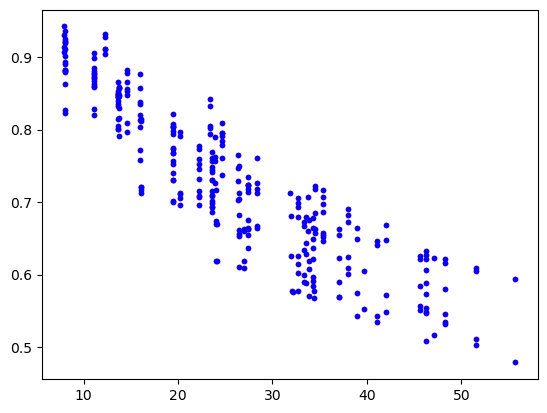

In [ ]:
plt.plot(rcorr['vdist'],rcorr['vcorr'],'.',c='r')
plt.plot(rcorr_v2['vdist'],rcorr_v2['vcorr'],'.',c='b')